In [ ]:
import pandas as pd
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [ ]:
df.shape

(5100, 9)

Q1. Missing Data Identification

Scenario: The hospital suspects incomplete patient records.

Task:

Identify missing values in each column

Calculate percentage of missing data

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64


Q2. Handling Missing Age

Scenario: Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)

In [ ]:
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
print(df['Age'].isnull().sum())

0


/tmp/ipykernel_30522/2811364376.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


For hospital patient age data, median imputation is preferred because patient ages may contain outliers and skewed distribution, making median more reliable and medically appropriate.


Q3. Handling Missing Treatment Cost

Scenario: Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why

In [ ]:
median_cost = df['Treatment_Cost']. median()
df['Treatment_Cost'].fillna(median_cost,inplace=True)
print(df['Treatment_Cost'].isnull().sum())

0


/tmp/ipykernel_30522/926995667.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_cost,inplace=True)


Treatment_Cost contains extreme expensive treatment values and is highly skewed, median imputation is the most appropriate method because it is resistant to outliers and better represents the typical patient cost.

Q4. Duplicate Patient Records

Scenario: Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [ ]:
duplicate_rows = df[df.duplicated(subset='Patient_ID')]
print("Duplicate Patient Records:")
print(duplicate_rows)


Duplicate Patient Records:
      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
148        19555  11.0    Male  Hyderabad  Hypertension                9   
184        17392  45.0  Female     Mumbai      COVID-19                1   
235        16287  80.0    Male    Chennai           Flu                2   
258        15592  93.0  Female     Mumbai           Flu               15   
278        14555  58.0  Female      Delhi           Flu               13   
...          ...   ...     ...        ...           ...              ...   
5095       11764  50.0  Female     Mumbai      COVID-19               15   
5096       17597  50.0  Female    Chennai        Asthma                2   
5097       19171  50.0  Female     Mumbai           Flu                1   
5098       13854  50.0  Female  Bangalore           Flu               17   
5099       14859  50.0    Male      Delhi  Hypertension               19   

      Treatment_Cost  Insurance_Coverage Admission_Date  
14

In [ ]:
print("\nNumber of Duplicate Patient_IDs:")
print(df['Patient_ID'].duplicated().sum())


Number of Duplicate Patient_IDs:
1215


In [ ]:
print("\nDataset Size Before Removing Duplicates:")
print(df.shape)


Dataset Size Before Removing Duplicates:
(5100, 9)


In [ ]:
df_cleaned = df.drop_duplicates(subset='Patient_ID')

In [ ]:
print("\nDataset Size After Removing Duplicates:")
print(df_cleaned.shape)


Dataset Size After Removing Duplicates:
(3885, 9)


Q5. Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them

In [ ]:
# Detect invalid age values
import pandas as pd



# Detect unrealistic age values
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

# Display invalid records
print("Invalid Age Records:")
print(invalid_age)

# Count invalid records
print("\nNumber of Invalid Ages:")
print(len(invalid_age))


Invalid Age Records:
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []

Number of Invalid Ages:
0


Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [ ]:
import pandas as pd

Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
]

print("Number of Outliers:", len(outliers))
print(outliers)

Number of Outliers: 50
      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
53         13152  91.0  Female    Chennai      COVID-19               13   
86         10064  28.0  Female  Hyderabad  Hypertension               16   
124        17035  59.0    Male      Delhi           Flu                9   
183        15855  36.0    Male     Mumbai      Diabetes                1   
215        19561  29.0    Male     Mumbai           Flu               16   
332        11686  51.0    Male      Delhi        Asthma               16   
382        10876  58.0  Female  Bangalore  Hypertension                1   
416        14070  50.0    Male  Hyderabad           Flu                6   
452        10851  42.0  Female  Bangalore      COVID-19               15   
796        18150  37.0  Female  Bangalore           Flu               17   
833        19361  41.0  Female      Delhi      Diabetes               19   
1127       10943  26.0  Female      Delhi        Asthma          

Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [ ]:
lower_cap = df['Treatment_Cost']. quantile(0.5)
upper_cap = df['Treatment_Cost']. quantile(0.95)

df['Treatment_Cost'] = df['Treatment_Cost'].clip(
    lower = lower_cap ,
    upper = upper_cap
)
print(df['Treatment_Cost'].describe())

count     5100.000000
mean     30499.665882
std       8035.486437
min      24797.000000
25%      24797.000000
50%      24797.000000
75%      36309.500000
max      47918.000000
Name: Treatment_Cost, dtype: float64


Q8. Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df['Log_Treatment_Cost'] = np.log(df['Treatment_Cost'])

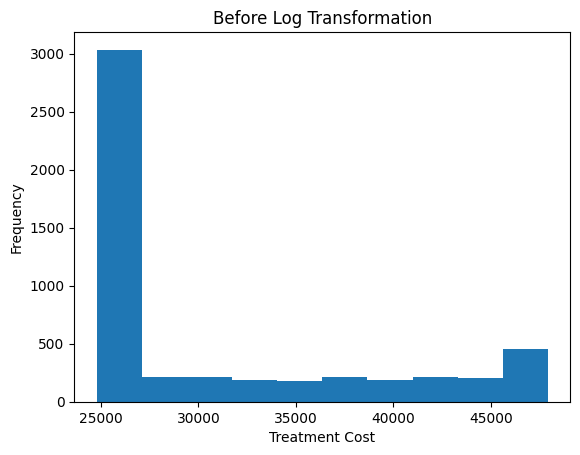

In [ ]:
plt.hist(df['Treatment_Cost'])
plt.title("Before Log Transformation")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()

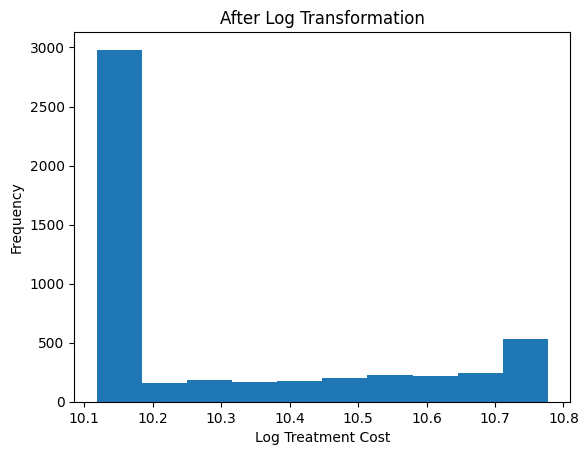

In [ ]:
plt.hist(df['Log_Treatment_Cost'])
plt.title("After Log Transformation")
plt.xlabel("Log Treatment Cost")
plt.ylabel("Frequency")
plt.show()

Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice


In [ ]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

In [ ]:
df = df.sort_values(by='Admission_Date')

In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_30522/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
print(df.isnull().sum())

Patient_ID            0
Age                   0
Gender                0
City                  0
Diagnosis             0
Hospital_Visits       0
Treatment_Cost        0
Insurance_Coverage    0
Admission_Date        0
Log_Treatment_Cost    0
dtype: int64
